In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [12]:
url = "https://github.com/subathaks/Machine-Learning-Lab/raw/refs/heads/main/Sales_Analysis_Dataset%20%283%29%20%281%29.xlsx"

df = pd.read_excel(url)

print("Dataset loaded successfully!")
print(df.head())
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

Dataset loaded successfully!
   Order_ID Order_Date Customer_Name Customer_Segment Product_Name  \
0  ORD00001 2023-08-17     Suresh 90      Home Office       Laptop   
1  ORD00002 2023-03-03    Suresh 430         Consumer      Monitor   
2  ORD00003 2024-07-23     Sneha 105         Consumer       Laptop   
3  ORD00004 2025-01-05      Vijay 81      Home Office   Headphones   
4  ORD00005 2025-01-10     Priya 876         Consumer      Pen Set   

     Category Sub_Category Region        City  Quantity  ...      Sales  \
0  Technology    Computers   East      Ranchi         4  ...  195496.56   
1  Technology  Accessories  North  Chandigarh         4  ...   59495.44   
2  Technology    Computers  North  Chandigarh         7  ...  415866.46   
3  Technology  Accessories   East       Patna         1  ...    2324.90   
4  Stationery      Writing  North       Delhi         2  ...     292.28   

      Profit  Payment_Method  Year Month  Month_Number Quarter  Profit_Margin  \
0   44744.06      

In [13]:
X = df[
    [
        "Quantity",
        "Unit_Price",
        "Discount",
        "Profit",
        "Profit_Margin",
        "Year",
        "Month_Number"
    ]
]

y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   Quantity  Unit_Price  Discount     Profit  Profit_Margin  Year  \
0         4    59602.61      0.18   44744.06          22.89  2023   
1         4    15024.10      0.01    7362.22          12.37  2023   
2         7    61884.89      0.04  120845.34          29.06  2024   
3         1     2672.30      0.13     683.72          29.41  2025   
4         2      155.47      0.06      41.99          14.37  2025   

   Month_Number  
0             8  
1             3  
2             7  
3             1  
4             1  

Target:
0    195496.56
1     59495.44
2    415866.46
3      2324.90
4       292.28
Name: Sales, dtype: float64


In [14]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

X = X.fillna(X.median())
y = y.fillna(y.median())

print("\nMissing values handled.")

Missing values in X:
Quantity         0
Unit_Price       0
Discount         0
Profit           0
Profit_Margin    0
Year             0
Month_Number     0
dtype: int64

Missing values in y:
0

Missing values handled.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 7)
Testing data: (1000, 7)


In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [17]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 13301916672.0000 - mae: 58697.9102 - val_loss: 16003268608.0000 - val_mae: 68055.4062
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13294669824.0000 - mae: 58669.8633 - val_loss: 15984713728.0000 - val_mae: 67995.8125
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13262663680.0000 - mae: 58570.2383 - val_loss: 15922738176.0000 - val_mae: 67819.7344
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13184186368.0000 - mae: 58335.9258 - val_loss: 15791575040.0000 - val_mae: 67468.3750
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13039849472.0000 - mae: 57934.4961 - val_loss: 15577481216.0000 - val_mae: 66906.3906
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12813927424.0000 - mae: 57316.5117 - val_loss: 15251042304.0000 - val_mae: 66069.8125
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12502133760.0000 - mae: 56488.5039 - val_loss: 14828490752.0000 

In [20]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", loss)
print("Test MAE:", mae)

Test Loss: 626264896.0
Test MAE: 13705.03515625


In [21]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicted Sales:
[[3.5942191e+04]
 [4.7468922e+05]
 [2.9431736e+04]
 [1.8560080e+02]
 [1.4467342e+05]
 [1.8176784e+05]
 [5.3701367e+04]
 [1.5824123e+04]
 [1.2578593e+03]
 [8.8088234e+04]]


In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 13705.031103426514
MSE: 626264825.6945918
RMSE: 25025.283728553244
R² Score: 0.9404921839363093


In [23]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred.flatten()
})

print(results.head(10))

   Actual Sales  Predicted Sales
0      24852.10     35942.191406
1     492568.78    474689.218750
2      50784.48     29431.736328
3       5186.46       185.600800
4     164672.46    144673.421875
5     195823.16    181767.843750
6      52471.86     53701.367188
7      21966.33     15824.123047
8       9830.41      1257.859253
9      87008.77     88088.234375


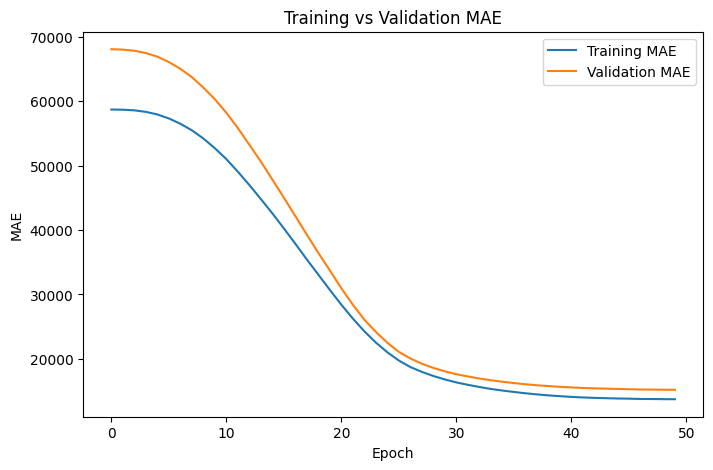

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

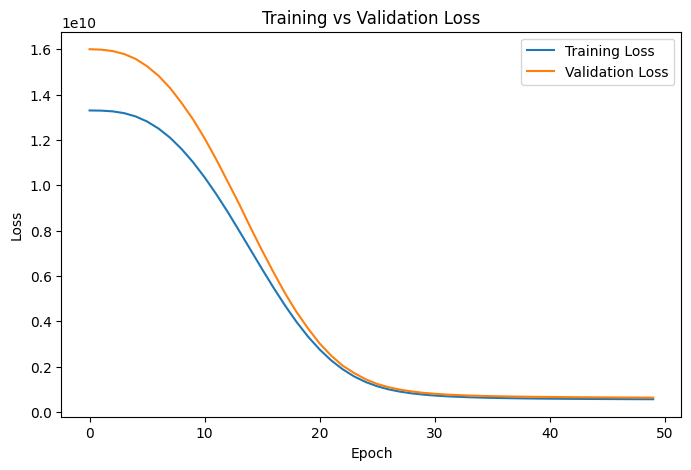

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

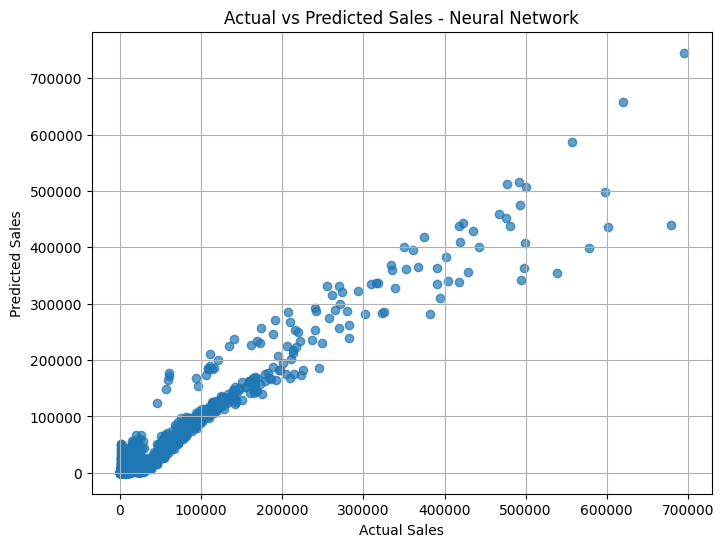

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred.flatten(),
    alpha=0.7
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Neural Network")

plt.grid(True)

plt.show()

In [27]:
results.to_excel(
    "Neural_Network_Sales_Predictions.xlsx",
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [28]:
model.save("sales_neural_network_model.keras")

print("Model saved successfully.")

Model saved successfully.
